In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [63]:
df=pd.read_csv("housing.csv")
df=df.drop("ocean_proximity",axis=1)

df.rename(columns={"median_house_value":"Price"},inplace=True)
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,Price
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0


In [75]:
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].mean())
X=df.drop("Price",axis=1)
y=df["Price"]
y = y / 100000

In [76]:
X.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
dtype: int64

In [77]:
X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462


In [78]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [79]:
X_train

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
14196,-117.03,32.71,33.0,3126.0,627.0,2300.0,623.0,3.2596
8267,-118.16,33.77,49.0,3382.0,787.0,1314.0,756.0,3.8125
17445,-120.48,34.66,4.0,1897.0,331.0,915.0,336.0,4.1563
14265,-117.11,32.69,36.0,1421.0,367.0,1418.0,355.0,1.9425
2271,-119.80,36.78,43.0,2382.0,431.0,874.0,380.0,3.5542
...,...,...,...,...,...,...,...,...
11284,-117.96,33.78,35.0,1330.0,201.0,658.0,217.0,6.3700
11964,-117.43,34.02,33.0,3084.0,570.0,1753.0,449.0,3.0500
5390,-118.38,34.03,36.0,2101.0,569.0,1756.0,527.0,2.9344
860,-121.96,37.58,15.0,3575.0,597.0,1777.0,559.0,5.7192


In [80]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [81]:
import torch
X_train_tensor=torch.tensor(X_train_scaled,dtype=torch.float32)
y_train_tensor=torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)

X_test_tensor=torch.tensor(X_test_scaled,dtype=torch.float32)
y_test_tensor=torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

In [82]:
from torch.utils.data import TensorDataset , DataLoader
train_dataset=TensorDataset(X_train_tensor,y_train_tensor)
test_dataset=TensorDataset(X_test_tensor,y_test_tensor)

train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32)

In [83]:
import torch.nn as nn
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()

        self.model = nn.Sequential(
        #1st hidden layer
        nn.Linear(X_train.shape[1],6),
        nn.ReLU(),

        #2nd hidden layer
        nn.Linear(6,6),
        nn.ReLU(),

        #output
        nn.Linear(6,1)
    )
    def forward(self,x):
        return self.model(x)

In [90]:
criterion=nn.MSELoss()
import torch.optim as optim
model=ANN()
optimizer=optim.Adam(model.parameters(),lr=0.005)

In [94]:
epochs=50
train_loss=[]
validation_loss=[]
best_val_loss=float("inf")
for epoch in range(epochs):
    model.train()
    train_epoch_loss=0.0
    
    for xb,yb in train_loader:
        
        optimizer.zero_grad()
        outputs=model(xb)
        loss=criterion(outputs,yb)
        loss.backward()
        optimizer.step()
        
        train_epoch_loss+=loss.item()
    average_train_loss=train_epoch_loss/len(train_loader)
    train_loss.append(average_train_loss)
    
    val_epoch_loss=0.0
    model.eval()
    with torch.no_grad():
        for xb,yb in test_loader:
            
            outputs=model(xb)
            loss=criterion(outputs,yb)
            val_epoch_loss+=loss.item()
            
        average_val_loss=val_epoch_loss/len(test_loader)
        validation_loss.append(average_val_loss)
            
    print(f"Epoch {epoch+1}/{epochs} => Train Loss = {average_train_loss:.4f} | Val Loss = {average_val_loss:.4f}")
    if average_val_loss < best_val_loss:
        best_val_loss=average_val_loss
        torch.save(model.state_dict(),"best_practice_model")

Epoch 1/50 => Train Loss = 0.3404 | Val Loss = 0.3534
Epoch 2/50 => Train Loss = 0.3405 | Val Loss = 0.3850
Epoch 3/50 => Train Loss = 0.3383 | Val Loss = 0.3597
Epoch 4/50 => Train Loss = 0.3411 | Val Loss = 0.3519
Epoch 5/50 => Train Loss = 0.3388 | Val Loss = 0.3529
Epoch 6/50 => Train Loss = 0.3391 | Val Loss = 0.3523
Epoch 7/50 => Train Loss = 0.3381 | Val Loss = 0.3531
Epoch 8/50 => Train Loss = 0.3381 | Val Loss = 0.3608
Epoch 9/50 => Train Loss = 0.3379 | Val Loss = 0.3579
Epoch 10/50 => Train Loss = 0.3384 | Val Loss = 0.3548
Epoch 11/50 => Train Loss = 0.3378 | Val Loss = 0.3528
Epoch 12/50 => Train Loss = 0.3388 | Val Loss = 0.3664
Epoch 13/50 => Train Loss = 0.3376 | Val Loss = 0.3564
Epoch 14/50 => Train Loss = 0.3365 | Val Loss = 0.3574
Epoch 15/50 => Train Loss = 0.3372 | Val Loss = 0.3639
Epoch 16/50 => Train Loss = 0.3386 | Val Loss = 0.3527
Epoch 17/50 => Train Loss = 0.3371 | Val Loss = 0.3556
Epoch 18/50 => Train Loss = 0.3387 | Val Loss = 0.3562
Epoch 19/50 => Trai

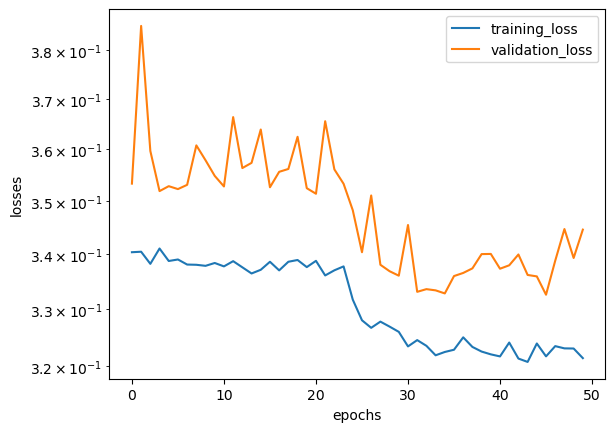

In [96]:
import matplotlib.pyplot as plt 
loss_df=pd.DataFrame(
    {
        "training_loss":train_loss,
        "validation_loss":validation_loss
    }
)
plt.plot(loss_df["training_loss"],label="training_loss")
plt.plot(loss_df["validation_loss"],label="validation_loss")
plt.xlabel("epochs")
plt.ylabel("losses")
plt.yscale('log') 
plt.legend()

In [97]:
model.load_state_dict(torch.load("best_practice_model"))

<All keys matched successfully>

In [100]:
#evaluate
model.eval()
with torch.no_grad():
    train_pred=model(X_train_tensor)
    test_pred=model(X_test_tensor)

    train_mse_loss=criterion(train_pred,y_train_tensor)
    test_mse_loss=criterion(test_pred,y_test_tensor)

    print("MSE train :",train_mse_loss.item())
    print("MSE test :",test_mse_loss.item())

    

MSE train : 0.3149653673171997
MSE test : 0.33263421058654785


In [102]:
from sklearn.metrics import r2_score
print("r^2 score = ",r2_score(y_test,test_pred))

r^2 score =  0.7461600141729654
